In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("GPU Available:", tf.config.list_physical_devices('GPU'))

# 1. Cargar datos
data_dir = 'D:/2do_cuatri_erasmus/intro_computer_vision_and_quality_control/project/data/DATA_Maguire_20180517_ALL/final'
batch_size = 32
img_height = 224
img_width = 224

train_dataset = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="training", seed=123,
  image_size=(img_height, img_width), batch_size=batch_size, follow_links=False)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="validation", seed=123,
  image_size=(img_height, img_width), batch_size=batch_size, follow_links=False)

class_names = train_dataset.class_names

# 2. Optimización en memoria
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# 3. Calcular pesos
total_cracked = 8484
total_non_cracked = 47608
total_images = total_cracked + total_non_cracked

class_weight = {
    0: (1 / total_cracked) * (total_images / 2.0), 
    1: (1 / total_non_cracked) * (total_images / 2.0)
}
print("\nDatos cargados y pesos calculados.")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 56092 files belonging to 2 classes.
Using 44874 files for training.
Found 56092 files belonging to 2 classes.
Using 11218 files for validation.

Datos cargados y pesos calculados.


In [2]:
# 1. Arquitectura
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2), 
    tf.keras.layers.RandomContrast(0.2)  
], name="data_augmentation")

base_model = tf.keras.applications.ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])

# 2. Entrenar
print("Arrancando entrenamiento de Fase 2 (10 épocas)...")
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=10, class_weight=class_weight)

# 3. Guardar modelo inicial
model.save('modelo_fase2_resnet.h5')
print("\n¡MODELO BASE GUARDADO en el disco duro!")

Arrancando entrenamiento de Fase 2 (10 épocas)...
Epoch 1/10
1403/1403 [==============================] - 781s 409ms/step - loss: 0.4776 - accuracy: 0.8006 - recall: 0.8153 - val_loss: 0.3057 - val_accuracy: 0.8946 - val_recall: 0.9429
Epoch 2/10
1403/1403 [==============================] - 611s 436ms/step - loss: 0.4446 - accuracy: 0.8251 - recall: 0.8416 - val_loss: 0.2933 - val_accuracy: 0.9009 - val_recall: 0.9482
Epoch 3/10
1403/1403 [==============================] - 641s 457ms/step - loss: 0.4390 - accuracy: 0.8294 - recall: 0.8465 - val_loss: 0.2982 - val_accuracy: 0.9022 - val_recall: 0.9463
Epoch 4/10
1403/1403 [==============================] - 641s 457ms/step - loss: 0.4315 - accuracy: 0.8318 - recall: 0.8484 - val_loss: 0.3015 - val_accuracy: 0.8977 - val_recall: 0.9373
Epoch 5/10
1403/1403 [==============================] - 659s 470ms/step - loss: 0.4347 - accuracy: 0.8329 - recall: 0.8495 - val_loss: 0.2913 - val_accuracy: 0.9041 - val_recall: 0.9454
Epoch 6/10
1403/1403

In [3]:
print("Iniciando Fine-Tuning (Descongelando ResNet50)...")

# 1. Descongelamos el modelo base
base_model.trainable = True

# 2. Re-compilamos el modelo (Learning rate minúsculo)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])

# 3. Entrenamos 5 épocas más
history_fine = model.fit(train_dataset, validation_data=validation_dataset, epochs=5, class_weight=class_weight)

# 4. Guardamos la versión final
model.save('modelo_fase2_finetuned.h5')
print("\n¡MODELO FINE-TUNED GUARDADO en el disco duro!")

Iniciando Fine-Tuning (Descongelando ResNet50)...
Epoch 1/5
1403/1403 [==============================] - 1871s 1s/step - loss: 0.3854 - accuracy: 0.8742 - recall: 0.8953 - val_loss: 0.2278 - val_accuracy: 0.9333 - val_recall: 0.9690
Epoch 2/5
1403/1403 [==============================] - 1303s 928ms/step - loss: 0.3411 - accuracy: 0.8938 - recall: 0.9121 - val_loss: 0.1870 - val_accuracy: 0.9377 - val_recall: 0.9808
Epoch 3/5
1403/1403 [==============================] - 1118s 797ms/step - loss: 0.3279 - accuracy: 0.8971 - recall: 0.9144 - val_loss: 0.1948 - val_accuracy: 0.9421 - val_recall: 0.9802
Epoch 4/5
1403/1403 [==============================] - 741s 528ms/step - loss: 0.3196 - accuracy: 0.8995 - recall: 0.9160 - val_loss: 0.1943 - val_accuracy: 0.9405 - val_recall: 0.9770
Epoch 5/5
1403/1403 [==============================] - 758s 540ms/step - loss: 0.3118 - accuracy: 0.9022 - recall: 0.9183 - val_loss: 0.2160 - val_accuracy: 0.9350 - val_recall: 0.9635

¡MODELO FINE-TUNED GUARD

Extrayendo etiquetas reales y calculando predicciones del modelo Fine-Tuned...

351/351 [==============================] - 34s 95ms/step
=== RESULTADOS FINE-TUNED (UMBRAL 0.5) ===
              precision    recall  f1-score   support

     Cracked       0.79      0.78      0.78      1708
 Non_Cracked       0.96      0.96      0.96      9510

    accuracy                           0.94     11218
   macro avg       0.88      0.87      0.87     11218
weighted avg       0.93      0.94      0.93     11218


=== RESULTADOS FINE-TUNED (UMBRAL 0.8) ===
              precision    recall  f1-score   support

     Cracked       0.43      0.91      0.58      1708
 Non_Cracked       0.98      0.78      0.87      9510

    accuracy                           0.80     11218
   macro avg       0.70      0.85      0.73     11218
weighted avg       0.90      0.80      0.83     11218



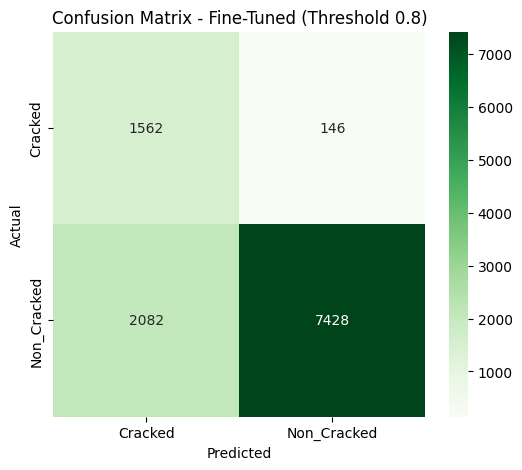

In [4]:
print("Extrayendo etiquetas reales y calculando predicciones del modelo Fine-Tuned...\n")
val_labels = np.concatenate([y for x, y in validation_dataset], axis=0)
val_preds_probs_fine = model.predict(validation_dataset)

# --- EVALUACIÓN 1: UMBRAL ESTÁNDAR (0.5) ---
val_preds_50 = (val_preds_probs_fine > 0.5).astype(int).flatten()
print("=== RESULTADOS FINE-TUNED (UMBRAL 0.5) ===")
print(classification_report(val_labels, val_preds_50, target_names=class_names))

# --- EVALUACIÓN 2: UMBRAL EXIGENTE (0.8) ---
umbral_exigente = 0.80 
val_preds_80 = (val_preds_probs_fine > umbral_exigente).astype(int).flatten()
print(f"\n=== RESULTADOS FINE-TUNED (UMBRAL {umbral_exigente}) ===")
print(classification_report(val_labels, val_preds_80, target_names=class_names))

# Pintamos la matriz del umbral exigente (la que irá al paper)
cm_80 = confusion_matrix(val_labels, val_preds_80)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_80, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - Fine-Tuned (Threshold {umbral_exigente})')
plt.show()